Import the libraries

In [ ]:
import zipfile
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

from sklearn.kernel_ridge import KernelRidge
import matplotlib.pyplot as plt


Dataset

In [ ]:
zip_path = "/content/competitive-data-science-predict-future-sales.zip"

with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall("sales_data")

df = pd.read_csv("sales_data/sales_train.csv")
df.head()

,date,date_block_num,shop_id,item_id,item_price,item_cnt_day
0,02.01.2013,0,59,22154,999.00,1.0
1,03.01.2013,0,25,2552,899.00,1.0
2,05.01.2013,0,25,2552,899.00,-1.0
3,06.01.2013,0,25,2554,1709.05,1.0
4,15.01.2013,0,25,2555,1099.00,1.0


Data Processing
and Seasonality Features
> Add blockquote



In [ ]:
monthly_sales = (
    df.groupby(["date_block_num", "shop_id", "item_id", "item_price"], as_index=False)
      .agg({"item_cnt_day": "sum"})
)

monthly_sales.rename(columns={"item_cnt_day": "monthly_sales"}, inplace=True)


upper_limit = monthly_sales["monthly_sales"].quantile(0.99)
monthly_sales["monthly_sales"] = np.clip(
    monthly_sales["monthly_sales"], None, upper_limit
)
# ---------- After monthly_sales is created, add seasonality features ----------
# First, ensure the data is sorted by time for correct lag creation
monthly_sales = monthly_sales.sort_values(['shop_id', 'item_id', 'date_block_num'])

# Extract month and year from date_block_num (assuming 0 = month 1, year 0)
monthly_sales['month'] = (monthly_sales['date_block_num'] % 12) + 1
monthly_sales['year'] = monthly_sales['date_block_num'] // 12

# Create lagged sales (e.g., sales 1, 2, 3, and 6 months ago)
lags = [1, 2, 3, 6]
for lag in lags:
    monthly_sales[f'lag_{lag}'] = (
        monthly_sales.groupby(['shop_id', 'item_id'])['monthly_sales']
                     .shift(lag)
    )

# Rolling mean of last 3 months (excluding current month)
monthly_sales['rolling_mean_3'] = (
    monthly_sales.groupby(['shop_id', 'item_id'])['monthly_sales']
                 .transform(lambda x: x.shift(1).rolling(3, min_periods=1).mean())
)

# Price change from previous month (proxy for promotions)
monthly_sales['price_change'] = (
    monthly_sales.groupby(['shop_id', 'item_id'])['item_price']
                 .pct_change()
)

# ---------- External factors (if you have items.csv and shops.csv) ----------
# Load additional data
items = pd.read_csv("sales_data/items.csv")
shops = pd.read_csv("sales_data/shops.csv")

# Merge item category
monthly_sales = monthly_sales.merge(items[['item_id', 'item_category_id']], on='item_id', how='left')
# Merge shop city (extract from shop_name)
shops['shop_city'] = shops['shop_name'].str.split().str[0]   # simple heuristic
monthly_sales = monthly_sales.merge(shops[['shop_id', 'shop_city']], on='shop_id', how='left')

# Encode categorical variables
from sklearn.preprocessing import LabelEncoder
le_city = LabelEncoder()
le_cat = LabelEncoder()
monthly_sales['shop_city_enc'] = le_city.fit_transform(monthly_sales['shop_city'].astype(str))
monthly_sales['category_enc'] = le_cat.fit_transform(monthly_sales['item_category_id'].astype(str))

# Drop rows with NaN created by lags/pct_change
monthly_sales.dropna(subset=[f'lag_{lag}' for lag in lags] +
                            ['rolling_mean_3', 'price_change'], inplace=True)

# Now define X and y with all features
feature_columns = [
    'date_block_num', 'shop_id', 'item_id', 'item_price',
    'month', 'year',
    'lag_1', 'lag_2', 'lag_3', 'lag_6',
    'rolling_mean_3', 'price_change',
    'shop_city_enc', 'category_enc'
]
X = monthly_sales[feature_columns]
y = monthly_sales['monthly_sales']



Feature and Target Selection

In [ ]:
X = monthly_sales[feature_columns]
y = monthly_sales['monthly_sales']


Train-Test Split

In [ ]:
# Chronological split: use last 6 months as test
last_date = monthly_sales['date_block_num'].max()
test_start = last_date - 5   # last 6 months (including last)
train_idx = monthly_sales['date_block_num'] < test_start
test_idx = monthly_sales['date_block_num'] >= test_start

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

# Clip extreme sales only on training data to avoid leakage
upper_limit = y_train.quantile(0.99)
y_train = np.clip(y_train, None, upper_limit)

Scaling

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


MLPRegressor

In [ ]:
from sklearn.neural_network import MLPRegressor

model = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    solver="adam",
    max_iter=50,
    random_state=42
)

model.fit(X_train_scaled, y_train)


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=50, random_state=42)

Prediction and Evaluation

In [ ]:
y_pred = model.predict(X_test_scaled)

from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)


MAE : 0.8497938117649989
MSE : 2.037267388375991
RMSE: 1.427328759738271


Error Distribution plot

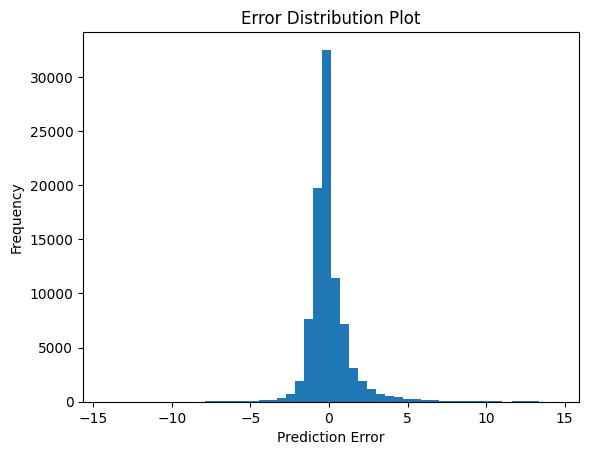

In [ ]:
errors = y_test - y_pred

import matplotlib.pyplot as plt
plt.figure()
plt.hist(errors, bins=50)
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
plt.title("Error Distribution Plot")
plt.show()


New sample(input)

In [ ]:
sample_product = pd.DataFrame({
    "date_block_num": [34],
    "shop_id": [5],
    "item_id": [5037],
    "item_price": [1200]
})


Scale+Predict(sales)

In [ ]:
# After you have the full monthly_sales DataFrame (including all features)
sample_shop = 5
sample_item = 5037
sample_price = 1200   # you can use current price or the last known price
sample_month = 34     # the future month you want to predict

# Get the historical data for this shop/item
history = monthly_sales[(monthly_sales['shop_id'] == sample_shop) &
                        (monthly_sales['item_id'] == sample_item)].sort_values('date_block_num')

# Check if we have enough history
if len(history) >= 6:
    lag_1 = history['monthly_sales'].iloc[-1]
    lag_2 = history['monthly_sales'].iloc[-2]
    lag_3 = history['monthly_sales'].iloc[-3]
    lag_6 = history['monthly_sales'].iloc[-6]
    rolling_mean_3 = history['monthly_sales'].iloc[-3:].mean()
    # Price change from the last month
    price_change = (history['item_price'].iloc[-1] / history['item_price'].iloc[-2]) - 1
    # Use the last known category and city encodings
    category_enc = history['category_enc'].iloc[-1]
    shop_city_enc = history['shop_city_enc'].iloc[-1]
else:
    # Fallback if not enough history (use averages or zeros)
    lag_1 = lag_2 = lag_3 = lag_6 = rolling_mean_3 = price_change = 0
    category_enc = monthly_sales[monthly_sales['item_id']==sample_item]['category_enc'].iloc[0]
    shop_city_enc = monthly_sales[monthly_sales['shop_id']==sample_shop]['shop_city_enc'].iloc[0]

# Create the sample DataFrame with all features
sample_features = pd.DataFrame([{
    'date_block_num': sample_month,
    'shop_id': sample_shop,
    'item_id': sample_item,
    'item_price': sample_price,
    'month': (sample_month % 12) + 1,
    'year': sample_month // 12,
    'lag_1': lag_1,
    'lag_2': lag_2,
    'lag_3': lag_3,
    'lag_6': lag_6,
    'rolling_mean_3': rolling_mean_3,
    'price_change': price_change,
    'shop_city_enc': shop_city_enc,
    'category_enc': category_enc
}])

# Scale and predict
sample_scaled = scaler.transform(sample_features)
predicted_sales = model.predict(sample_scaled)
print("Predicted Monthly Sales:", predicted_sales[0])

Predicted Monthly Sales: 1.632534830940104


Price Prediction

In [ ]:
# After obtaining predicted_sales[0] as above:

# ===== Improved Dynamic Pricing =====
# Get the product's average monthly sales from training data (to avoid look‑ahead)
train_mask = train_idx  # Boolean series from your chronological split
product_history_train = monthly_sales[train_mask &
                                      (monthly_sales['shop_id'] == sample_shop) &
                                      (monthly_sales['item_id'] == sample_item)]

if len(product_history_train) > 0:
    avg_sales = product_history_train['monthly_sales'].mean()
else:
    # Fallback: use overall average if no history for this product (unlikely after lags)
    avg_sales = monthly_sales[train_mask]['monthly_sales'].mean()

# Parameters for pricing logic
sensitivity = 0.05          # 5% price change per unit of relative deviation
min_change = 0.95           # can decrease to 95% of current price
max_change = 1.15           # can increase to 115% of current price

# Calculate relative deviation from average
if avg_sales > 0:
    deviation = (predicted_sales[0] - avg_sales) / avg_sales
else:
    deviation = 0.0

# Compute adjustment factor and clamp to bounds
adjustment = 1.0 + sensitivity * deviation
adjustment = max(min_change, min(max_change, adjustment))

# Apply to current price
current_price = float(input("Enter the current price: "))
predicted_price = current_price * adjustment

print(f"Predicted Dynamic Price: {predicted_price:.2f}")
print(f"(Adjustment factor: {adjustment:.3f}, deviation: {deviation:.3f})")


Enter the current price: 1253
Predicted Dynamic Price: 1237.28
(Adjustment factor: 0.987, deviation: -0.251)
